In [1]:
#torchvision是专门针对视觉的包，具有常见数据集的数据加载器和用于图像的数据转换器
#即torchvision.datasets,torch.utils.data_DataLoader()
#采用CIFAR10d的数据集，彩色三通道，像素大小为32*32

In [2]:
#1.加载并规范化CIFAR10
import torch
import torchvision
import torchvision.transforms as transforms

In [3]:
#torchvision的数据集的输出是【0，1】的PILImage图像,需要转化为【-1，1】的归一化张量
transform=transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])#(x - mean) / std
batch_size=4
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,
                                     download=True,transform=transform)
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,
                                       shuffle=True,num_workers=2)
#shuflle:打乱 
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
classes=('plane','car','bird','cat',
        'deer','dog','frog','horse','ship','truck')

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


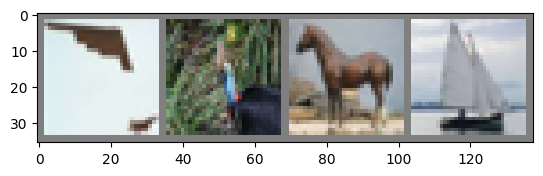

plane bird  horse ship 


In [7]:
#展示训练图像
import matplotlib.pyplot as plt
import numpy as np
def imshow(img):
    img=img/2+0.5
    npimg=img.numpy()
    #调整维度顺序:PyTorch使用 (C, H, W)格式，matplotlib需要 (H, W, C)格式
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()
#创建迭代器    
dataiter=iter(trainloader)
#加载数据
images,labels=next(dataiter)

#图像  grid:网格
imshow(torchvision.utils.make_grid(images))
#标签
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [8]:
#定义卷积神经网络
import torch.nn as nn
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,6,5)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(6,16,5)
        self.fc1=nn.Linear(16*5*5,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)

    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=torch.flatten(x,1)#保持批量维度
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x
net=Net()

In [9]:
#定义损失函数和优化
import torch.optim as optim
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(net.parameters(),lr=0.001,momentum=0.9)

In [10]:
#训练网络
for epoch in range(2):
    running_loss=0.0
    for i,data in enumerate(trainloader,0):
        inputs,labels=data
        optimizer.zero_grad()
        outputs=net(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
        if i%2000==1999:
            print(f'[{epoch+1},{i+1:5d}] loss: {running_loss/2000:.3f}')
            running_loss=0.0
print('Finished Traning')

[1, 2000] loss: 2.224
[1, 4000] loss: 1.937
[1, 6000] loss: 1.723
[1, 8000] loss: 1.634
[1,10000] loss: 1.528
[1,12000] loss: 1.484
[2, 2000] loss: 1.394
[2, 4000] loss: 1.388
[2, 6000] loss: 1.353
[2, 8000] loss: 1.326
[2,10000] loss: 1.302
[2,12000] loss: 1.251
Finished Traning


In [11]:
PATH='./cifar_net.pth'
torch.save(net.state_dict(),PATH)

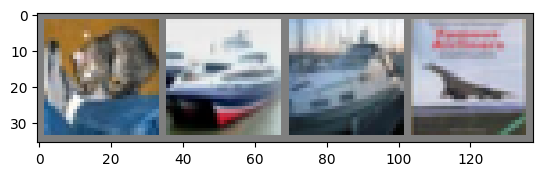

GroundTruth: cat   ship  ship  plane


In [14]:
dataiter=iter(testloader)
images,labels=next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth:',' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [15]:
outputs=net(images)
_,predicted=torch.max(outputs,1)
print('Predicted: ',' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  cat   plane car   plane


In [16]:
correct=0
total=0
with torch.no_grad():#禁用梯度计算
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)#样本数
        correct+=(predicted==labels).sum().item()#.item(): 将张量转换为Python数值
print(f'Accuracy of the network on the 10000 test images:{100*correct//total}%')

Accuracy of the network on the 10000 test images:54%


In [19]:
#字典推导式  {key: value for item in iterable}
correct_pred={classname: 0 for classname in classes}
total_pred={classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predictions=torch.max(outputs,1)
        for label,prediction in zip(labels,predictions):
            if label==prediction:
                correct_pred[classes[label]]+=1
            total_pred[classes[label]]+=1
for classname,correct_count in correct_pred.items():
    accuracy=100*float(correct_count)/total_pred[classname]
    print(f'Accuracy for class:{classname:5s}  is {accuracy:.1f} %')

Accuracy for class:plane  is 67.7 %
Accuracy for class:car    is 78.9 %
Accuracy for class:bird   is 36.8 %
Accuracy for class:cat    is 18.6 %
Accuracy for class:deer   is 35.4 %
Accuracy for class:dog    is 59.4 %
Accuracy for class:frog   is 76.0 %
Accuracy for class:horse  is 53.9 %
Accuracy for class:ship   is 61.2 %
Accuracy for class:truck  is 56.8 %
